In [68]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

import tqdm

import sys
import os



### First part: Convergence without spinnaker library

In [69]:

#########################################################
################@Copyright from sandilabs################
#########################################################
def generate_gamma_sparse(n_sys, neurons_per_mesh_point, gamma_norm):   
    '''
    Generates the Gamma matrix mapping neurons to readout variables.  
    n_sys: number of readout variables
    neurons_per_mesh_point: number of neurons to place at each mesh node
    gamma_norm:  Magnitude of the readout kernel for each neuron
    
    '''
    
    n_neurons = neurons_per_mesh_point * n_sys

    gamma_data = []
    gamma_row = []
    gamma_col = []
    for pt in range(n_sys):
      
        start_idx = pt * neurons_per_mesh_point
        half_npm = neurons_per_mesh_point//2
        
        gamma_row.extend(neurons_per_mesh_point*[pt])
        gamma_col.extend(list(range(start_idx, start_idx + neurons_per_mesh_point)))
        gamma_data.extend(half_npm*[-gamma_norm])
        gamma_data.extend(half_npm*[gamma_norm])
         
    return sp.sparse.csr_array((np.array(gamma_data), (np.array(gamma_row), np.array(gamma_col))), shape=(n_sys, n_neurons))

#########################################################
################@Copyright from sandilabs################
#########################################################
def create_spiking_fem_network_sparse(A_sys, gamma, gamma_norm, lambda_d=10, lambda_v=20, mu=1e-6, nu=1e-5, tau_A=0.1):
    '''
    Generates sparse weight matrices, thresholds, and reset voltages for a NeuroFEM network implementing the
    linear system A_sys with readout kernel gamma
    '''
    n_sys, n_neurons = gamma.shape
    gTg = (gamma.T) @ gamma
    omega_f = gTg + mu*(lambda_d**2) * sp.sparse.eye_array(n_neurons)
    
    GTAG = (gamma.T) @ (A_sys / tau_A) @ gamma  # should be sparse
    
    threshs = 0.5 * (nu*lambda_d**2 + (gamma_norm**2) * np.ones(n_neurons))
    v_reset = threshs - (gamma_norm**2 + mu*(lambda_d**2)) * np.ones(n_neurons)
    omega_f = omega_f - (gamma_norm**2 + mu*(lambda_d**2)) * sp.sparse.eye_array(n_neurons)

    return omega_f, GTAG, threshs, v_reset



def read_csr_matrx(mtx_filename):
    try:
    
        raw_data = np.loadtxt(mtx_filename, skiprows=1, dtype=float)
        
        
        with open(mtx_filename, 'r') as f:
            header = f.readline().split()
            n_rows = int(header[0])
            n_cols = int(header[1])


        rows = raw_data[:, 0].astype(int) - 1
        cols = raw_data[:, 1].astype(int) - 1
        values = raw_data[:, 2]


        A = sp.sparse.csr_matrix((values, (rows, cols)), shape=(n_rows, n_cols))


        initial_nnz = A.nnz
        A.eliminate_zeros()
        print(f"Shape: {A.shape}")
        print(f"Non-zeros: {A.nnz}")

        return A
    except Exception as e:
        print(f"Failed to load matrix: {e}")
        sys.exit(1)



def read_vec(filename):
    try:
        b = np.loadtxt(filename, dtype=float, skiprows=1)
        return b
    except Exception as e:
        print(f"Failed to load RHS: {e}")
        sys.exit(1)

In [70]:
problem_name = "Sphere_00"
    
mtx_filename = f"{problem_name}_mtx.txt"
rhs_filename = f"{problem_name}_rhs.txt"
sol_filename = f"{problem_name}_sol.txt"

data_directory = "data/matrix/"

print(os.getcwd())

A = read_csr_matrx(data_directory + mtx_filename)
b = read_vec(data_directory + rhs_filename)
x_sol = read_vec("data/solution/" + sol_filename)

x_analytical = read_vec("data/solution/" + "Sphere_00_analytical_rhs.txt")



/home/amirbouslama/Documents/Studium/Neuromorphic-Lab-TUM/NeuromorphicSolver
Shape: (41, 41)
Non-zeros: 403


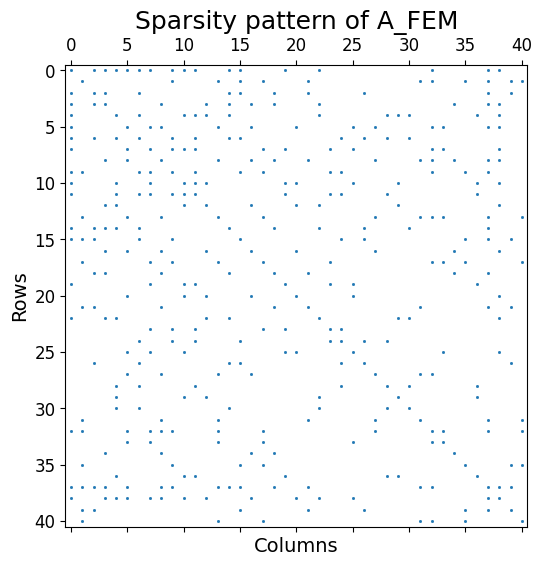

In [71]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(A, markersize=1)
plt.title("Sparsity pattern of A_FEM", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

In [72]:
#### Converting the matrix

#### The power of two defining the magnitude of gamma

############################################################
############# @Copyright from sandilabs ####################
############################################################
gamma_pow2 = -6 # In the paper, we used gamma = 2^-6 or gamma = 2^-8
s_gamma = 7 - gamma_pow2
gamma_norm = (2**gamma_pow2 - 2**-s_gamma)

#### The power of two to which we rescale the slow weight matrix
omega_s_pow2 = 1 
omega_max = 2**omega_s_pow2 - 2**-(7-omega_s_pow2)


#### network parameters
lambda_d = 8              # Hz; slow variable time constant.  Default = 10 Hz
lambda_v = 16             # Hz; membrane potential time constant. Default = 20 Hz

ki = 16                   # integral control gain
kp = 4                    # proportional control gain


N_interior = A.shape[0]
neurons_per_mesh_point = 16
n_neurons = neurons_per_mesh_point * N_interior
        
sigma_v = 0.00225 # We kept this constant for all meshes
tau_A = (gamma_norm**2) * np.amax(np.abs(A))/omega_max
mu = 0  # spike L2 norm penalization; set to 0
nu = 0  # spike L1 norm penalization; set to 0

# create system
gamma = generate_gamma_sparse(N_interior, neurons_per_mesh_point, gamma_norm)
# Added gamma_norm in the correct position
omega_f, GTAG, threshs, v_reset = create_spiking_fem_network_sparse(
    -A, 
    gamma, 
    gamma_norm, 
    lambda_d=lambda_d, 
    lambda_v=lambda_v, 
    mu=mu, 
    nu=nu, 
    tau_A=tau_A
)

dt = 2**(-12)             # power of two
n_timesteps = 100000

# neuron biases
bias_f1 = gamma.T @ (b / tau_A)

In [73]:
n_sys, n_neurons = gamma.shape

# Initialize variables
V = np.zeros(n_neurons)
spikes = np.zeros((n_neurons, 1), dtype=np.int8)
output = np.zeros((n_sys, n_timesteps))

# Feedback current (u1) and Integral error (u_int)
u1 = np.zeros(n_neurons)
u_int = np.zeros(n_neurons)

# This input is constant for a static Ax=b problem
c_in_fixed_gamma = np.copy(bias_f1)

print("Starting simulation...")
for step in tqdm.tqdm(range(1, n_timesteps)):
    

    du1 = dt * (-lambda_d * u1) + GTAG @ spikes[:, 0]
    u1 += du1


    u_err = u1 + c_in_fixed_gamma
    

    u_int += dt * u_err
        
    dv = dt * (-lambda_v * V + kp * u_err + ki * u_int) \
         - omega_f.dot(spikes[:, 0]) \
         + sigma_v * np.random.randn(n_neurons)
    V += dv
        

    spikes[:, 0] = np.greater(V, threshs).astype(np.int8)


    has_spiked = spikes[:, 0] > 0
    V[has_spiked] = v_reset[has_spiked]


    output[:, step] = (1 - dt * lambda_d) * output[:, step-1] + gamma.dot(spikes[:, 0])

Starting simulation...


100%|██████████| 99999/99999 [00:17<00:00, 5603.25it/s]


Final Relative Error: 6.6295e-04


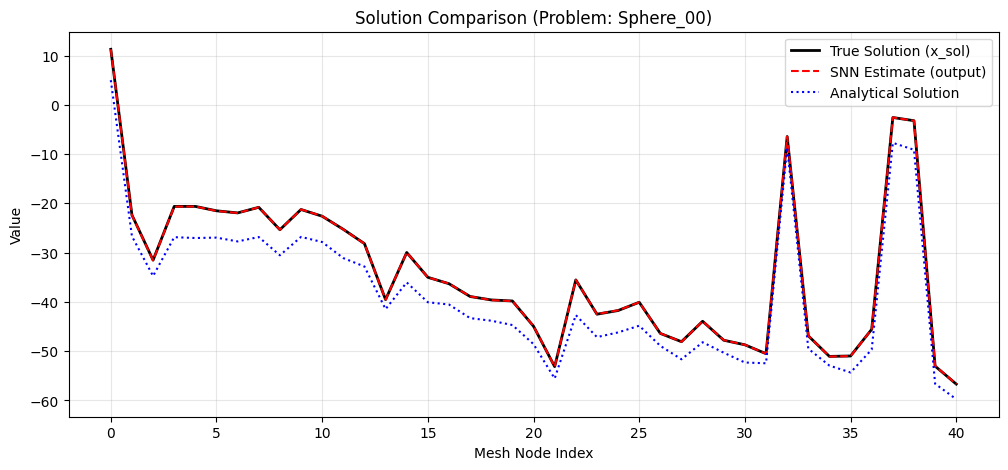

In [74]:

x_estimated = output[:, -1]


error_norm = np.linalg.norm(x_estimated - x_sol)
true_norm = np.linalg.norm(x_sol)
rel_error = error_norm / true_norm

print(f"========================================")
print(f"Final Relative Error: {rel_error:.4e}")
print(f"========================================")


plt.figure(figsize=(12, 5))


plt.plot(x_sol, 'k-', linewidth=2, label='True Solution (x_sol)')
plt.plot(x_estimated, 'r--', linewidth=1.5, label='SNN Estimate (output)')
plt.plot(x_analytical, 'b:', linewidth=1.5, label='Analytical Solution')
plt.title(f'Solution Comparison (Problem: {problem_name})')
plt.xlabel('Mesh Node Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)


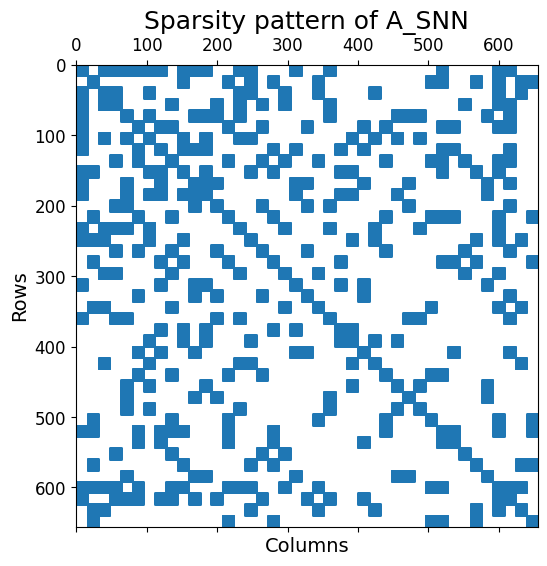

In [75]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(GTAG, markersize=1)
plt.title("Sparsity pattern of A_SNN", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

### Part 2: converter to spinnaker format

In [76]:

import brian2 #emulator for neuromorphic hardware
from spinnaker2 import snn, brian2_sim

In [86]:
import numpy as np
import scipy.sparse as sp
from spinnaker2 import snn, brian2_sim

###############################################################################
# 1. INPUT PROBLEM (SMALL TEST FEM SYSTEM)
###############################################################################

nmesh = A.shape[0]

###############################################################################
# 2. NEUROFEM CONFIG (MATCHES HARDWARE PARAMETERS)
###############################################################################

npm = 16                      # neurons per mesh point
gamma = 2.0 ** -6
lambda_d = 8.0
lambda_v = 16.0
k_p = 4.0
k_i = 16.0

theta = 0.5 * (gamma ** 2)

timesteps = 10000
sys_tick_in_s = 1e-3

###############################################################################
# 3. BUILD CONNECTION LIST (MATRIX → SPIKES)
###############################################################################

row_idx, col_idx = sp.csr_matrix(A).nonzero()
conns = []

for r, c in zip(row_idx, col_idx):
    weight = -A[r, c] * (gamma ** 2)
    for k in range(npm):
        conns.append([
            int(c * npm + k),   # pre neuron
            int(r * npm + k),   # post neuron
            float(weight),
            0                   # delay
        ])

###############################################################################
# 4. DEFINE CUSTOM NEUROFEM NEURON MODEL FOR BRIAN2
###############################################################################

# Neuron dynamics based on paper: membrane v, integral error u, spike output s
# y_readout approximates x for the mesh point

neuron_model_eqs = """
dv/dt = (-v + lambda_v*I_syn + k_p*u) / tau_v : 1 (unless refractory)
du/dt = -k_i * v : 1
I_syn : 1  # synaptic input from connected neurons
y_readout/dt = (-y_readout + Gamma * s) / tau_readout : 1
s : 1  # spike event (0 or 1)
"""

# Parameters for Brian2 dynamics
tau_v = 1.0
tau_readout = 10.0  # low-pass filter for spike-to-readout

# Gamma weights for each neuron to compute readout
Gamma = np.ones(npm) / npm  # half excitatory, half inhibitory can also be used

###############################################################################
# 5. CREATE NEUROFEM POPULATION
###############################################################################

nb_neurons = nmesh * npm

# Note: We use Brian2Backend wrapper
pop = snn.Population(
    size=nb_neurons,
    neuron_model="custom",  # tell spinnaker2 to use custom dynamics
    model_eqs=neuron_model_eqs,
    params={
        "tau_v": tau_v,
        "tau_readout": tau_readout,
        "Gamma": Gamma,
        "lambda_v": lambda_v,
        "k_p": k_p,
        "k_i": k_i,
        "threshold": theta,
        "v_reset": 0.0,
        "v_rest": 0.0,
        "I_syn": np.repeat(b * gamma, npm)
    },
    name="pop-neurofem",
    record=["spikes", "y_readout"]
)

pop.set_max_atoms_per_core(256)

###############################################################################
# 6. CREATE CONNECTIONS
###############################################################################

proj = snn.Projection(
    pre=pop,
    post=pop,
    connections=conns,
    name="proj-neurofem"
)

net = snn.Network("net-neurofem")
net.add(pop, proj)

###############################################################################
# 7. RUN EMULATOR
###############################################################################

print("Running Brian2 NeuroFEM emulation...")
hw = brian2_sim.Brian2Backend()
hw.run(net, time_steps=timesteps, sys_tick_in_s=sys_tick_in_s)

###############################################################################
# 8. DECODE SOLUTION FROM READOUT
###############################################################################

y_readout = pop.get_state("y_readout")  # returns array of readout for each neuron

x_est = np.zeros(nmesh)
for i in range(nmesh):
    x_est[i] = np.mean(y_readout[i*npm:(i+1)*npm])  # average over neurons at this mesh point

# Normalize for comparison
x_true_norm = x_true / np.linalg.norm(x_true)
x_est_norm = x_est / np.linalg.norm(x_est)

mse_norm = np.mean((x_true_norm - x_est_norm)**2)
print(f"Normalized MSE: {mse_norm:.6f}")


TypeError: Population.__init__() got an unexpected keyword argument 'model_eqs'

In [78]:
from spinnaker2 import brian2_sim
import inspect

print("--- Available attributes in brian2_sim ---")
# List all names in the module
print(dir(brian2_sim))

print("\n--- Classes in brian2_sim ---")
# Print only the classes (one of these is the hardware emulator)
for name, obj in inspect.getmembers(brian2_sim):
    if inspect.isclass(obj):
        print(f"Class: {name}")

--- Available attributes in brian2_sim ---
['Brian2Backend', 'Hz', 'SYNAPSE_ON_PRE', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'apply_neuron_param_to_lif_curr_exp_neuron_group', 'apply_neuron_param_to_lif_neuron_group', 'brian2', 'compute_decay', 'compute_tau', 'copy', 'eqs_lif', 'eqs_lif_curr_exp', 'lif_reset', 'ms', 'np', 'on_pre_action', 'quantize_clip', 'second', 'seed', 'snn', 'spinnaker2']

--- Classes in brian2_sim ---
Class: Brian2Backend


In [82]:
x_true_norm = x_true / np.linalg.norm(x_true)
x_snn_norm = x_est_raw / np.linalg.norm(x_est_raw)

mse_norm = np.mean((x_true_norm - x_snn_norm)**2)
print("Normalized MSE:", mse_norm)

Normalized MSE: 0.09306920351380613


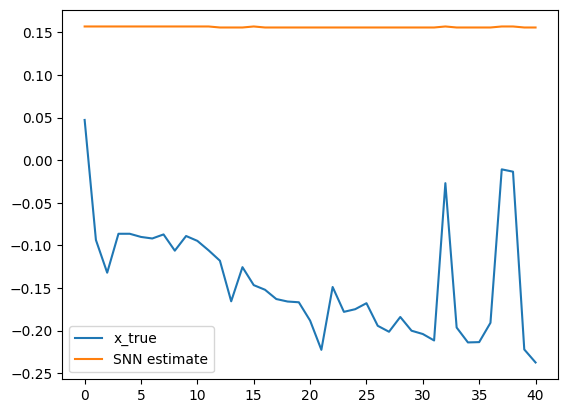

In [83]:
import matplotlib.pyplot as plt
plt.plot(x_true_norm, label="x_true")
plt.plot(x_snn_norm, label="SNN estimate")
plt.legend()
plt.show()